In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("netflix_titles.csv")

# Display first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [18]:
# Number of rows and columns
print("Shape:", df.shape)

# Information about columns
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Statistical summary
df.describe(include='all')

Shape: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


Dataset Summary
The dataset contains information about movies and TV shows available on Netflix.
It includes details such as title, director, cast, country, release year, rating, and duration.
The dataset has both numerical and categorical columns.
Some columns contain missing values that need to be cleaned.
This dataset can be used to analyze Netflix content trends and popularity.

In [19]:
# Make a copy of the original dataset
df_clean = df.copy()

# Check missing values
print(df_clean.isnull().sum())

# Fill missing values
df_clean['director'] = df_clean['director'].fillna('Unknown')
df_clean['cast'] = df_clean['cast'].fillna('Unknown')
df_clean['country'] = df_clean['country'].fillna('Unknown')
df_clean['rating'] = df_clean['rating'].fillna('Not Rated')

# Remove rows where date_added or duration is missing
df_clean = df_clean.dropna(subset=['date_added', 'duration'])

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Remove extra spaces
df_clean['date_added'] = df_clean['date_added'].str.strip()

# Convert to datetime
df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'],
    format='mixed',
    errors='coerce'
)

# Remove rows where conversion failed
df_clean = df_clean.dropna(subset=['date_added'])

# Check cleaned data
print("\nRemaining Missing Values:")
print(df_clean.isnull().sum())

print("\nNew Shape:", df_clean.shape)

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Remaining Missing Values:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

New Shape: (8794, 12)


Question 1: How many Movies and TV Shows are there?

In [20]:
# Count Movies and TV Shows
df_clean['type'].value_counts()

,count
type,
Movie,6128
TV Show,2666


Question 2: Which are the Top 10 countries with the most Netflix content?

In [21]:
df_clean['country'].value_counts().head(10)

,count
country,
United States,2809
India,972
Unknown,830
United Kingdom,418
Japan,244
South Korea,199
Canada,181
Spain,145
France,124


Question 3: Which are the Top 10 ratings?


In [22]:
df_clean['rating'].value_counts().head(10)

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


Question 4: How many titles were released each year?

In [23]:
df_clean['release_year'].value_counts().sort_index()

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1031
2018,1146
2019,1030


Question 5: What are the Top 10 Netflix genres?

In [24]:
df_clean['listed_in'].str.split(', ').explode().value_counts().head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1350
Documentaries,869
Action & Adventure,859
TV Dramas,762
Independent Movies,756
Children & Family Movies,641


Chart 1: Movies vs TV Shows (Bar Chart)

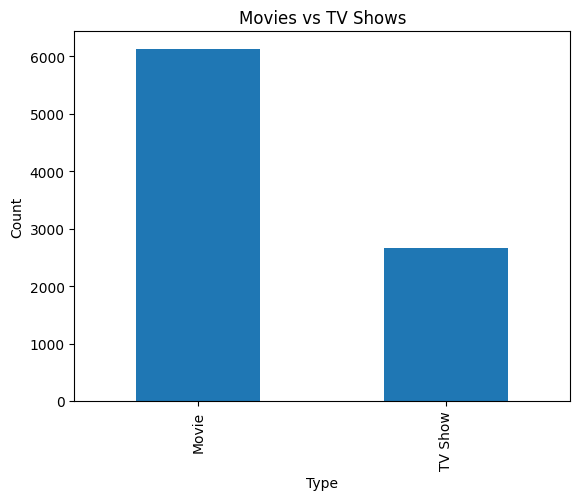

In [25]:
import matplotlib.pyplot as plt

df_clean['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

Chart 2: Content Released by Year (Line Chart)

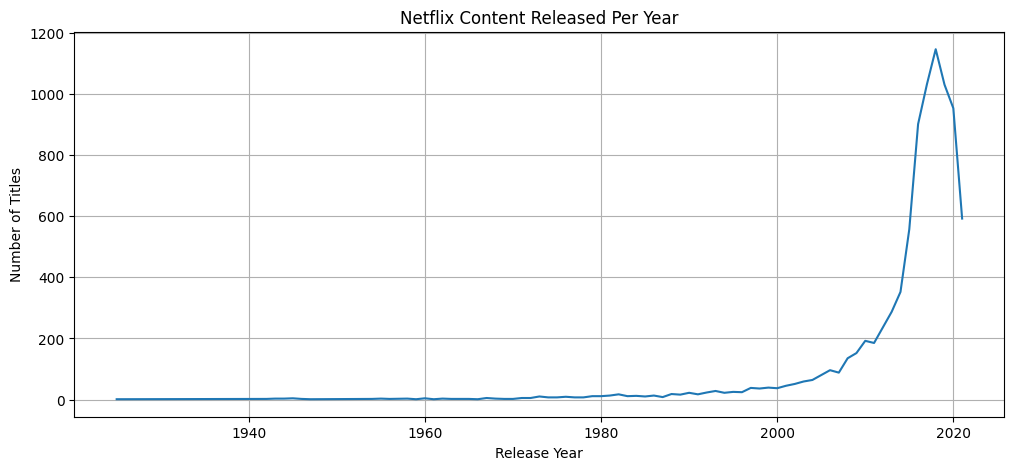

In [26]:
yearly = df_clean['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.plot(yearly.index, yearly.values)
plt.title("Netflix Content Released Per Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

Chart 3: Release Year Distribution (Histogram)

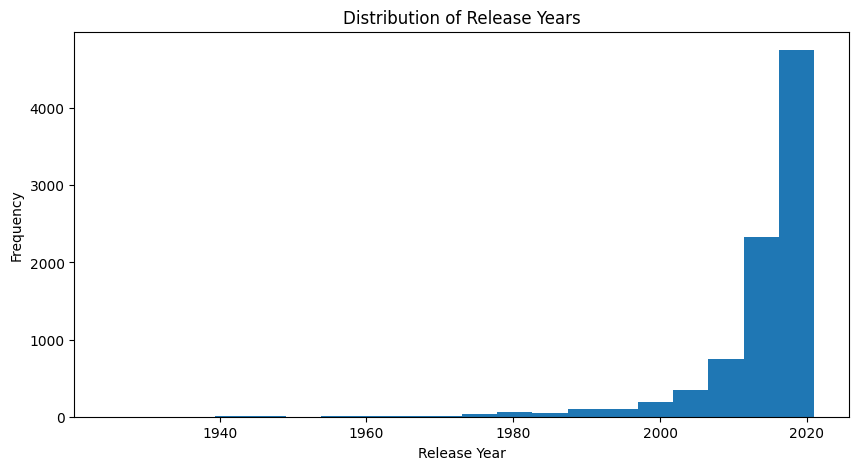

In [27]:
plt.figure(figsize=(10,5))
plt.hist(df_clean['release_year'], bins=20)
plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

Chart 4: Scatter Plot

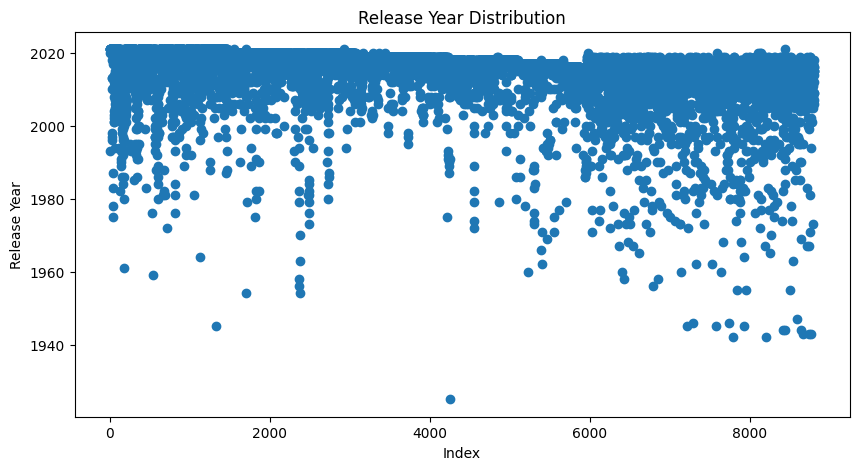

In [28]:
plt.figure(figsize=(10,5))
plt.scatter(df_clean.index, df_clean['release_year'])
plt.title("Release Year Distribution")
plt.xlabel("Index")
plt.ylabel("Release Year")
plt.show()

Chart 5: Movies vs TV Shows (Pie Chart)

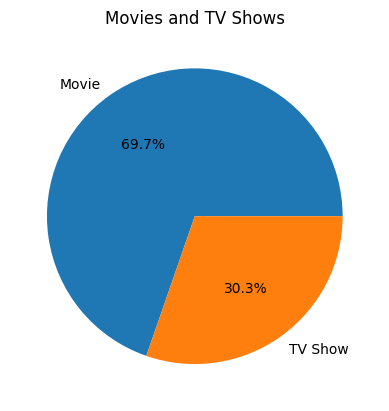

In [29]:
df_clean['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Movies and TV Shows")
plt.ylabel("")
plt.show()

Chart 6: Heatmap

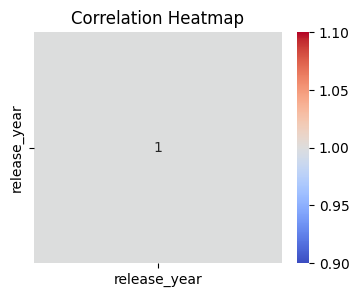

In [30]:
import seaborn as sns

numeric = df_clean[['release_year']]

plt.figure(figsize=(4,3))
sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Business Insights
1.Movies make up a significantly larger portion of Netflix's library than TV Shows, indicating a stronger focus on movie content.
2.The United States contributes the highest number of titles, followed by several other countries, showing Netflix's strong presence in those regions.
3.Most Netflix content was released in recent years, indicating rapid growth in content production.
4.TV-MA and TV-14 are among the most common content ratings, showing that Netflix mainly targets mature and teenage audiences.
5.International Movies and Dramas are among the most popular genres, reflecting Netflix's diverse global content strategy.

Most Surprising Finding

The most surprising finding was that Netflix contains significantly more movies than TV shows. Another interesting observation was the rapid increase in content released after 2015, showing how quickly Netflix expanded its content library. The analysis also highlighted the popularity of mature-rated content and international movies.